<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 5</b></center>    
<pre>    

# SVR

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read World bank CSV

In [3]:
data = pd.read_csv('WorldBank.csv')

In [5]:
data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [11]:
temp = data[data['Indicator Name'] == "Population ages 15-64 (% of total population)"]
temp

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


In [27]:
X = np.arange(1960, 2021).reshape(-1, 1)
# X

# Divide the data into input and output

In [36]:
X = np.arange(1960, 2020).reshape(-1, 1)
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

In [40]:
# y = temp.loc[:, '1960':'2020'].values.flatten()
# y
y = temp.values[0][4 : -1]
y

array([56.49748004, 56.17753236, 55.80745463, 55.46166361, 55.24893881,
       55.21135053, 55.09090078, 55.15534672, 55.34507283, 55.57014408,
       55.78194745, 55.85676846, 55.95268174, 56.07247186, 56.23447551,
       56.44405309, 56.49722595, 56.62068516, 56.78900152, 56.9691436,
       57.1425581, 57.18105454, 57.22630775, 57.28875038, 57.39054366,
       57.54142108, 57.55350984, 57.6545119, 57.81875323, 58.01501187,
       58.22990246, 58.37403848, 58.5472698, 58.75605047, 59.012126,
       59.31657719, 59.56507329, 59.8572303, 60.18600058, 60.53971518,
       60.90862046, 61.18898716, 61.4993847, 61.83084479, 62.173897,
       62.52276485, 62.80842981, 63.10261029, 63.40924784, 63.74196691,
       64.10821053, 64.429404, 64.80551944, 65.20848906, 65.5959799,
       65.94416405, 66.27426247, 66.53818711, 66.7667425, 67.00381119],
      dtype=object)

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

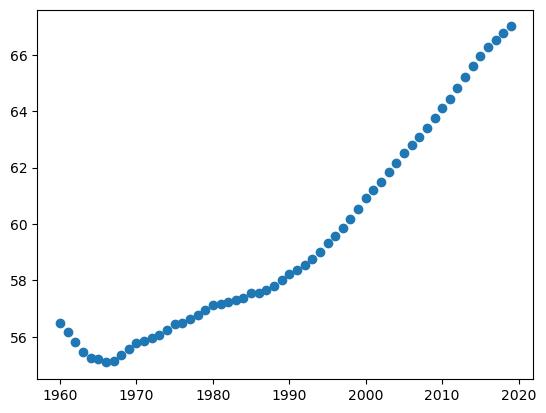

In [42]:
plt.scatter(X, y)

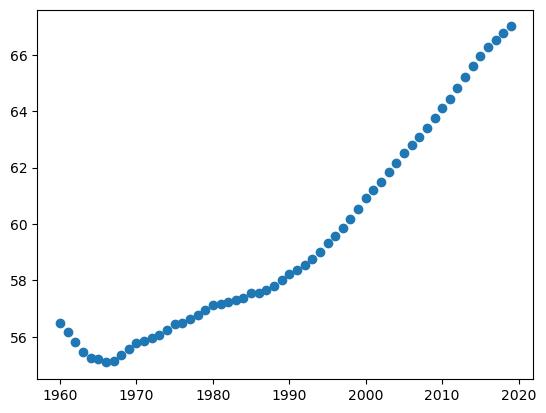

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [53]:
from sklearn.preprocessing import StandardScaler


In [61]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

y = y.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# print(X_scaled, y_scaled)



Scaling Complete.


# Splitting the dataset into the Training set and Test set

# Fitting SVR on 3 Different Kernel on dataset

In [96]:
from  sklearn.svm import SVR

model_linear = SVR(kernel="linear")

model_linear.fit(X_scaled, y_scaled.ravel())

y_pred_linear = model_linear.predict(X_scaled)

In [92]:
from  sklearn.svm import SVR

model_poly = SVR(kernel='poly')

model_poly.fit(X_scaled, y_scaled.ravel())

y_pred_poly = model_poly.predict(X_scaled)

In [98]:
from  sklearn.svm import SVR

model_rbf = SVR(kernel='rbf')

model_rbf.fit(X_scaled, y_scaled.ravel())


y_pred_rbf = model_rbf.predict(X_scaled)


In [102]:
new_y_linear = scaler_y.inverse_transform(y_pred_linear.reshape(-1, 1))
new_y_poly = scaler_y.inverse_transform(y_pred_poly.reshape(-1, 1))
new_y_rbf = scaler_y.inverse_transform(y_pred_rbf.reshape(-1, 1))

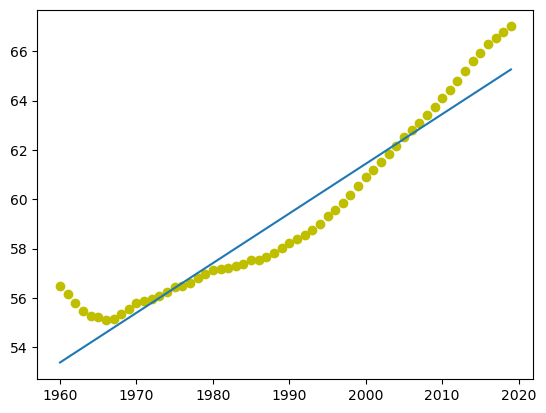

In [122]:
plt.scatter(X, y, color="y", label = "Data")
plt.plot(X, new_y_linear)

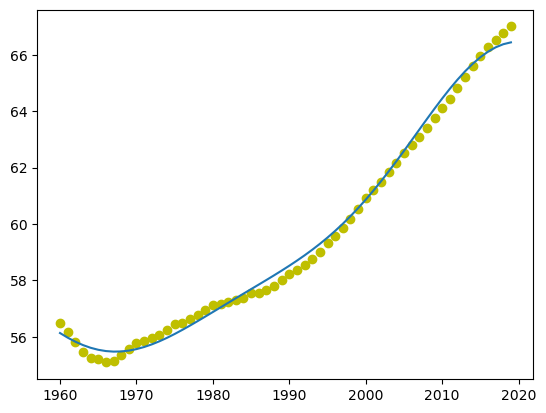

In [124]:
plt.scatter(X, y, color="y", label = "Data")
plt.plot(X, new_y_rbf)

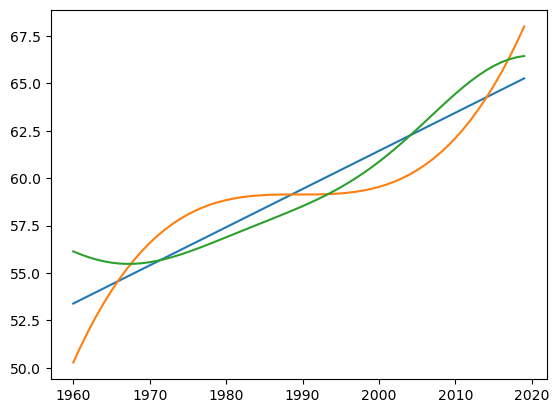

In [116]:
# plt.plot(X, y)
plt.plot(X, new_y_linear)
plt.plot(X, new_y_poly)
plt.plot(X, new_y_rbf)



SVR()

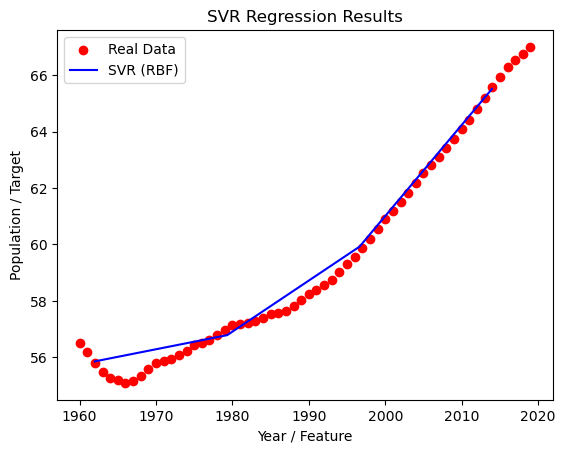

# Predict the x_test using 3 Kernel

In [ ]:
model_rbf.score(x_train,y_train)

0.9947138713539011

In [ ]:
model_rbf.score(x_test,y_test)

0.9880623181593732

array([57.55350984, 59.31657719, 67.00381119, 57.81875323, 55.85676846,
       55.80745463, 59.012126, 66.7667425, 60.90862046, 57.22630775,
       55.24893881, 55.78194745, 58.22990246, 61.18898716, 58.75605047,
       61.83084479, 63.74196691, 55.15534672], dtype=object)

array([57.73445326, 59.30206118, 64.8451716 , 57.99812952, 55.96479236,
       56.12587167, 59.06485884, 64.91876466, 60.76906052, 57.24445561,
       55.93360816, 55.89821768, 58.29641078, 61.1088798 , 58.84682535,
       61.81299688, 63.81278461, 55.81527994])

# Visualising the  results

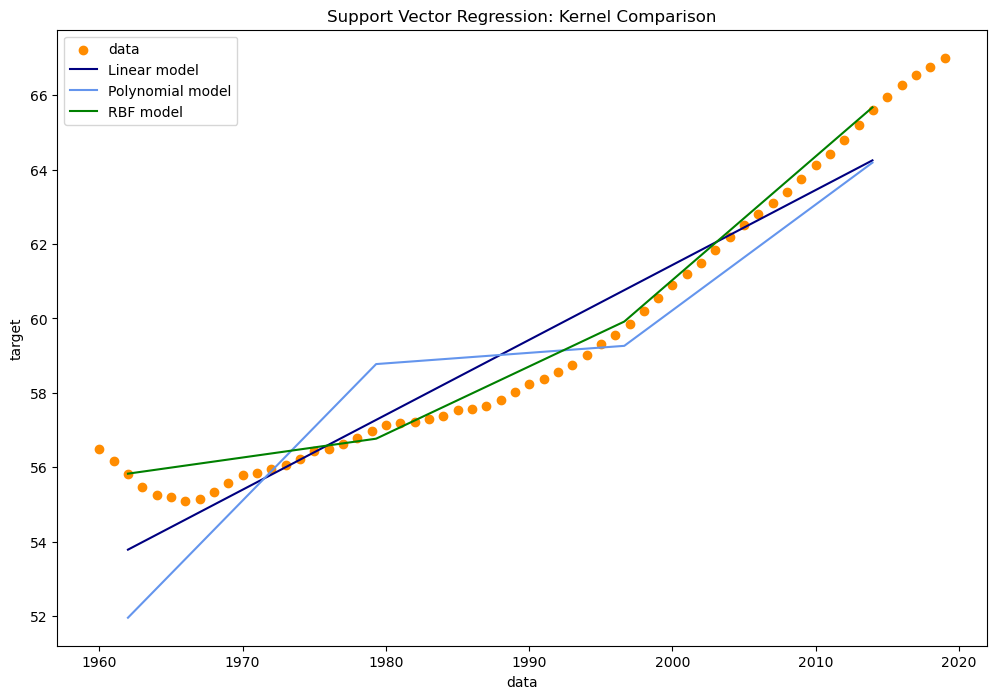

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

The predicted value for input 2025 is: 66.47
